Question 1(a).

In [ ]:
import pandas as pd
from datetime import datetime

# Sample data
data = {
    "Transaction ID": [12345, 12346, 12347, 12348, 12349, 12350, 12351],
    "Date": ["2024-12-01", "2024-12-01", "Invalid Date", "2024-12-01", "2024-12-02", "2024-12-02", "2024-12-01"],
    "Customer Name": ["John Doe", "Jane Smith", "", "John Doe", "Jane Smith", "John Doe", "Jane Smith"],
    "Transaction Amount": [100.50, None, 200.00, 1000.00, 105.50, 300.75, 100.50],
    "Currency": ["USD", "USD", "", "USD", "EURO", "USD", "USD"],
    "Account Number": ["001234567890", "001234567891", "001234567892", "", "001234567894", "001234567890", "001234567891"]
}

# Create DataFrame
df = pd.DataFrame(data)

# Helper function to validate dates
def validate_date(date):
    try:
        return datetime.strptime(date, "%Y-%m-%d")
    except ValueError:
        return None

# Cleaning process
df["Date"] = df["Date"].apply(validate_date)  # Fix invalid dates
df["Transaction Amount"] = pd.to_numeric(df["Transaction Amount"], errors="coerce")  # Handle missing/invalid amounts
df["Currency"] = df["Currency"].replace("", None)  # Replace empty strings with None
df["Customer Name"] = df["Customer Name"].replace("", None)  # Replace empty customer names with None
df["Account Number"] = df["Account Number"].replace("", None)  # Replace empty account numbers with None

# Highlight issues
df["Issues"] = ""
df.loc[df["Date"].isnull(), "Issues"] += "Invalid Date; "
df.loc[df["Transaction Amount"].isnull(), "Issues"] += "Missing Transaction Amount; "
df.loc[df["Currency"].isnull(), "Issues"] += "Missing Currency; "
df.loc[df["Customer Name"].isnull(), "Issues"] += "Missing Customer Name; "
df.loc[df["Account Number"].isnull(), "Issues"] += "Missing Account Number; "

# Print cleaned data and issues
print("Cleaned Data:")
print(df)

# Export to CSV for further review if needed
df.to_csv("cleaned_financial_data.csv", index=False)

Cleaned Data:
   Transaction ID       Date Customer Name  Transaction Amount Currency  \
0           12345 2024-12-01      John Doe              100.50      USD   
1           12346 2024-12-01    Jane Smith                 NaN      USD   
2           12347        NaT          None              200.00     None   
3           12348 2024-12-01      John Doe             1000.00      USD   
4           12349 2024-12-02    Jane Smith              105.50     EURO   
5           12350 2024-12-02      John Doe              300.75      USD   
6           12351 2024-12-01    Jane Smith              100.50      USD   

  Account Number                                             Issues  
0   001234567890                                                     
1   001234567891                       Missing Transaction Amount;   
2   001234567892  Invalid Date; Missing Currency; Missing Custom...  
3           None                           Missing Account Number;   
4   001234567894                   

Question 1 (c).

In [ ]:
import re

# Unstructured email body
email_body = """
Dear Client,
ur accnt balnce is negative. pls deposit $$ ASAP. thx, ABC Bank!
Trxn on 2024-12-22 for amt: 1k. Ref: INV123. More detals @ our portal.
"""

# Function to clean and extract structured information
def extract_financial_data(email):
    # Correct common abbreviations and typos
    email = email.lower()
    corrections = {
        "ur": "your",
        "accnt": "account",
        "balnce": "balance",
        "pls": "please",
        "thx": "thanks",
        "trxn": "transaction",
        "amt": "amount",
        "detals": "details"
    }
    for typo, correction in corrections.items():
        email = email.replace(typo, correction)

    # Extract structured information
    data = {
        "Account Status": None,
        "Transaction Date": None,
        "Transaction Amount": None,
        "Reference Number": None
    }

    # Detect account status
    if "balance is negative" in email:
        data["Account Status"] = "Negative Balance"

    # Extract transaction date
    date_match = re.search(r"\b\d{4}-\d{2}-\d{2}\b", email)
    if date_match:
        data["Transaction Date"] = date_match.group()

    # Extract transaction amount
    amount_match = re.search(r"amount:?\s*([\d\.]+[k]?)", email)
    if amount_match:
        amount_str = amount_match.group(1)
        if "k" in amount_str.lower():
            data["Transaction Amount"] = float(amount_str.lower().replace("k", "")) * 1000
        else:
            data["Transaction Amount"] = float(amount_str)

    # Extract reference number
    ref_match = re.search(r"ref[:]?[\s]?([a-zA-Z0-9]+)", email)
    if ref_match:
        data["Reference Number"] = ref_match.group(1)

    return data

# Extract data from the email
structured_data = extract_financial_data(email_body)

# Print the structured data
print("Extracted Structured Data:")
for key, value in structured_data.items():
    print(f"{key}: {value}")

Extracted Structured Data:
Account Status: Negative Balance
Transaction Date: 2024-12-22
Transaction Amount: 1000.0
Reference Number: inv123


Question 2 (a).

In [ ]:
!pip install pandas requests matplotlib
!pip install numpy pandas scipy matplotlib

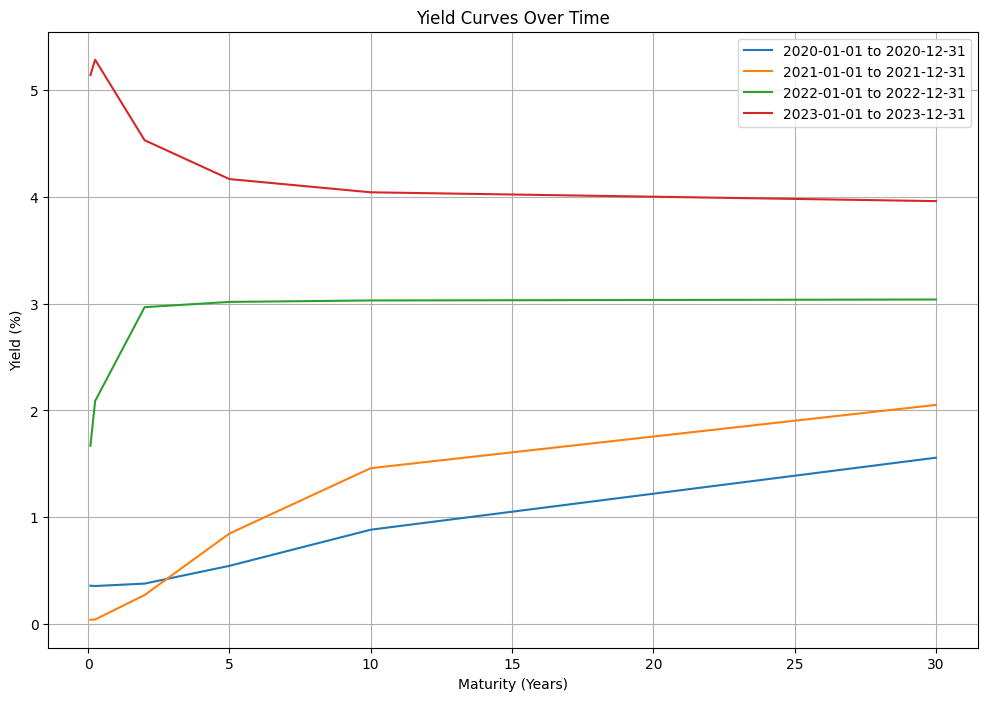

Parameters saved to yield_curve_parameters_over_time.csv
                     Period    Beta_0    Beta_1    Beta_2    Lambda
0  2020-01-01 to 2020-12-31  2.025880 -1.664381 -1.870206  3.989912
1  2021-01-01 to 2021-12-31  2.357383 -2.315772 -2.386891  1.952138
2  2022-01-01 to 2022-12-31  3.042400 -1.651689  1.311751  0.399408
3  2023-01-01 to 2023-12-31  3.917364  1.058174  2.680782  0.331175


In [ ]:
import requests
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# FRED API key
API_KEY = "57443c1085c66a19de80d0b344a555f1"

# Series IDs for Treasury yields
series_ids = {
    "DGS1MO": 0.083,  # 1-month
    "DGS3MO": 0.25,   # 3-month
    "DGS2": 2,        # 2-year
    "DGS5": 5,        # 5-year
    "DGS10": 10,      # 10-year
    "DGS30": 30       # 30-year
}

# Base URL for FRED API
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

# Nelson-Siegel function
def nelson_siegel(maturities, beta0, beta1, beta2, lambda_):
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_))
    term3 = beta2 * (((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_)) - np.exp(-maturities / lambda_))
    return term1 + term2 + term3

# Define time periods
time_periods = [
    ("2020-01-01", "2020-12-31"),
    ("2021-01-01", "2021-12-31"),
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
]

# Retrieve and model data for each time period
all_results = []
plt.figure(figsize=(12, 8))

for start_date, end_date in time_periods:
    # Retrieve data for all series
    dataframes = []
    for series_id, maturity in series_ids.items():
        params = {
            "series_id": series_id,
            "api_key": API_KEY,
            "file_type": "json",
            "observation_start": start_date,
            "observation_end": end_date
        }
        response = requests.get(BASE_URL, params=params)
        if response.status_code == 200:
            # Parse JSON response
            observations = response.json().get("observations", [])
            df = pd.DataFrame(observations)
            df["maturity"] = maturity
            df = df.rename(columns={"value": "yield"})
            df = df[["maturity", "yield"]]
            df["yield"] = pd.to_numeric(df["yield"], errors="coerce")  # Convert to numeric
            dataframes.append(df)
        else:
            print(f"Failed to retrieve data for {series_id} ({start_date} to {end_date}): {response.status_code}")

    # Combine data for the period
    combined_data = pd.concat(dataframes).dropna()

    # Fit the Nelson-Siegel model
    maturities = combined_data["maturity"].values
    yields = combined_data["yield"].values
    initial_guess = [3.0, -2.0, 1.0, 0.5]  # Initial parameter guesses
    params, _ = curve_fit(nelson_siegel, maturities, yields, p0=initial_guess)

    # Save results
    all_results.append({
        "Period": f"{start_date} to {end_date}",
        "Beta_0": params[0],
        "Beta_1": params[1],
        "Beta_2": params[2],
        "Lambda": params[3]
    })

    # Generate fitted yields
    fitted_yields = nelson_siegel(maturities, *params)

    # Plot yield curve for the period
    plt.plot(maturities, fitted_yields, label=f"{start_date} to {end_date}")

# Customize the plot
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curves Over Time")
plt.legend()
plt.grid()
plt.show()

# Save results to CSV
results_df = pd.DataFrame(all_results)
results_df.to_csv("yield_curve_parameters_over_time.csv", index=False)
print("Parameters saved to yield_curve_parameters_over_time.csv")

# Print parameter trends
print(results_df)

Question 2 (b).

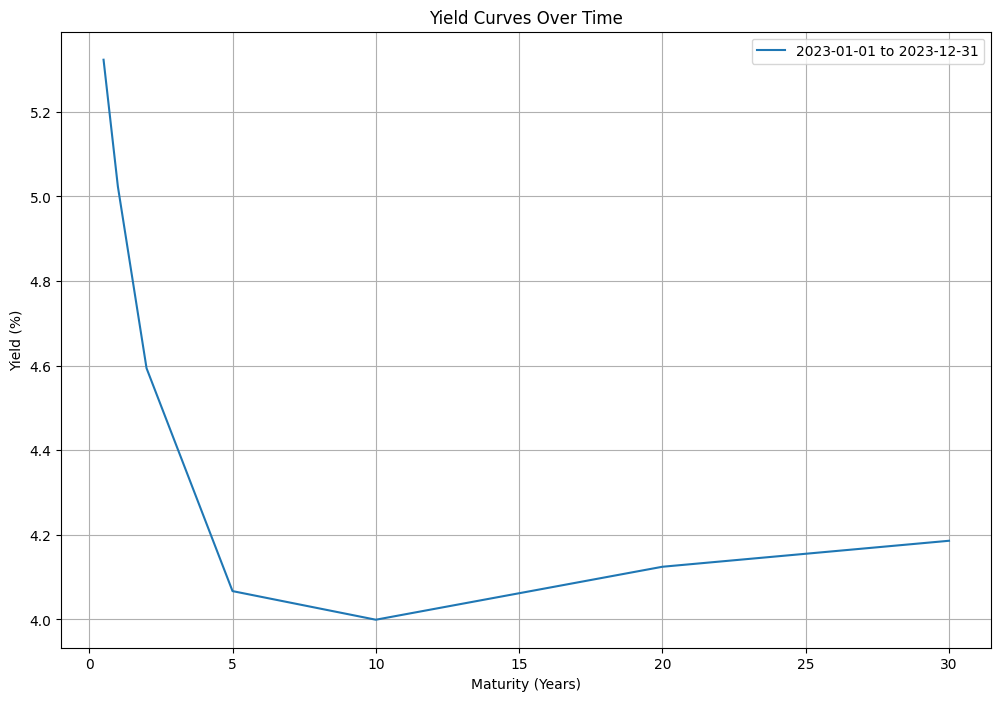

Parameters saved to yield_curve_parameters_over_time.csv
                     Period    Beta_0    Beta_1    Beta_2    Lambda
0  2023-01-01 to 2023-12-31  4.311167  1.386271 -2.861102  0.212187


In [ ]:
import requests
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# FRED API key
API_KEY = "57443c1085c66a19de80d0b344a555f1"

# Series IDs for Treasury yields (short-term to long-term)
series_ids = {
    "DGS6MO": 0.5,    # 6-month
    "DGS1": 1,        # 1-year
    "DGS2": 2,        # 2-year
    "DGS5": 5,        # 5-year
    "DGS10": 10,      # 10-year
    "DGS20": 20,      # 20-year
    "DGS30": 30       # 30-year
}

# Base URL for FRED API
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

# Nelson-Siegel function
def nelson_siegel(maturities, beta0, beta1, beta2, lambda_):
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_))
    term3 = beta2 * (((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_)) - np.exp(-maturities / lambda_))
    return term1 + term2 + term3

# Define time periods
time_periods = [
    ("2020-01-01", "2020-12-31"),
    ("2021-01-01", "2021-12-31"),
    ("2022-01-01", "2022-12-31"),
    ("2023-01-01", "2023-12-31"),
]

# Retrieve and model data for each time period
all_results = []
plt.figure(figsize=(12, 8))

for start_date, end_date in time_periods:
    # Retrieve data for all series
    dataframes = []
    for series_id, maturity in series_ids.items():
        params = {
            "series_id": series_id,
            "api_key": API_KEY,
            "file_type": "json",
            "observation_start": start_date,
            "observation_end": end_date
        }
        response = requests.get(BASE_URL, params=params)
        if response.status_code == 200:
            # Parse JSON response
            observations = response.json().get("observations", [])
            df = pd.DataFrame(observations)
            df["maturity"] = maturity
            df = df.rename(columns={"value": "yield"})
            df = df[["maturity", "yield"]]
            df.loc[:, "yield"] = pd.to_numeric(df["yield"], errors="coerce")  # Corrected assignment
            dataframes.append(df)
        else:
            print(f"Failed to retrieve data for {series_id} ({start_date} to {end_date}): {response.status_code}")

    # Combine data for the period
    combined_data = pd.concat(dataframes).dropna()

    # Fit the Nelson-Siegel model
    maturities = combined_data["maturity"].values
    yields = combined_data["yield"].values
    initial_guess = [2.0, -1.0, 0.5, 2.0]  # Beta_0, Beta_1, Beta_2, Lambda
    # Fit the Nelson-Siegel model with improved parameter handling
try:
    # Scale maturities to months to stabilize calculations
    scaled_maturities = maturities / 12
    params, _ = curve_fit(
        nelson_siegel, scaled_maturities, yields, p0=initial_guess,
        bounds=([0, -10, -10, 0.1], [10, 10, 10, 10]), maxfev=5000
    )

    # Generate fitted yields for plotting
    fitted_yields = nelson_siegel(scaled_maturities, *params)
    plt.plot(maturities, fitted_yields, label=f"{start_date} to {end_date}")

    # Save results
    all_results.append({
        "Period": f"{start_date} to {end_date}",
        "Beta_0": params[0],
        "Beta_1": params[1],
        "Beta_2": params[2],
        "Lambda": params[3]
    })

except RuntimeError as e:
    print(f"Curve fitting failed for {start_date} to {end_date}: {e}")

    # Generate fitted yields
    fitted_yields = nelson_siegel(maturities, *params)

    # Plot yield curve for the period
    plt.plot(maturities, fitted_yields, label=f"{start_date} to {end_date}")

# Customize the plot
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curves Over Time")
plt.legend()
plt.grid()
plt.show()

# Save results to CSV
results_df = pd.DataFrame(all_results)
results_df.to_csv("yield_curve_parameters_over_time.csv", index=False)
print("Parameters saved to yield_curve_parameters_over_time.csv")

# Print parameter trends
print(results_df)

Question 2 (c).

Fitted Parameters:
Beta0 (Level): 3.0586
Beta1 (Slope): -2.9209
Beta2 (Curvature): -0.0001
Lambda (Decay): 3.5038


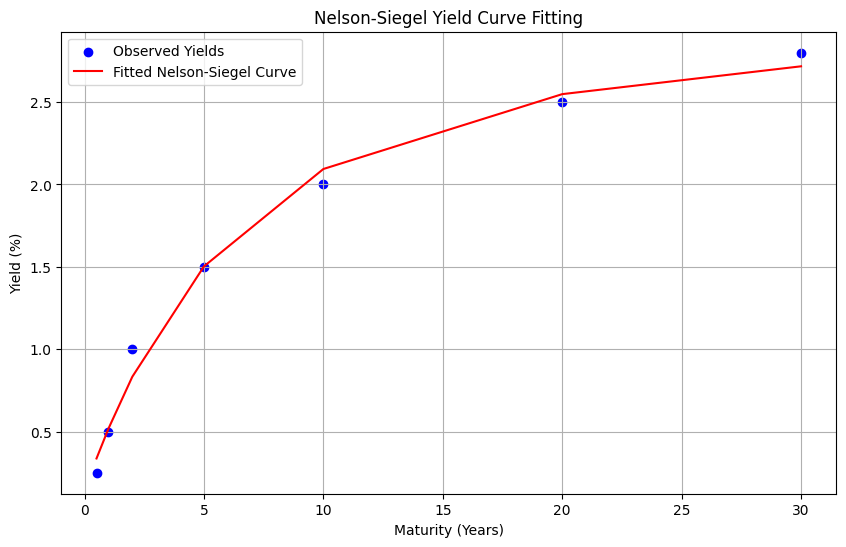

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Nelson-Siegel function
def nelson_siegel(maturities, beta0, beta1, beta2, lambda_):
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_))
    term3 = beta2 * (((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_)) - np.exp(-maturities / lambda_))
    return term1 + term2 + term3

# Maturities and yields (replace with your data)
maturities = np.array([0.5, 1, 2, 5, 10, 20, 30])  # Maturities in years (6M, 1Y, 2Y, etc.)
yields = np.array([0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 2.8])  # Corresponding yields

# Initial guesses for the parameters
initial_guess = [2.5, -1.0, 0.5, 0.5]  # Beta0, Beta1, Beta2, Lambda

# Fit the Nelson-Siegel model
params, _ = curve_fit(nelson_siegel, maturities, yields, p0=initial_guess)

# Extract fitted parameters
beta0, beta1, beta2, lambda_ = params
print(f"Fitted Parameters:\nBeta0 (Level): {beta0:.4f}\nBeta1 (Slope): {beta1:.4f}\nBeta2 (Curvature): {beta2:.4f}\nLambda (Decay): {lambda_:.4f}")

# Generate fitted yields
fitted_yields = nelson_siegel(maturities, beta0, beta1, beta2, lambda_)

# Plot observed vs. fitted yields
plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color="blue", label="Observed Yields")
plt.plot(maturities, fitted_yields, color="red", label="Fitted Nelson-Siegel Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Nelson-Siegel Yield Curve Fitting")
plt.legend()
plt.grid()
plt.show()

Question 2 (d).

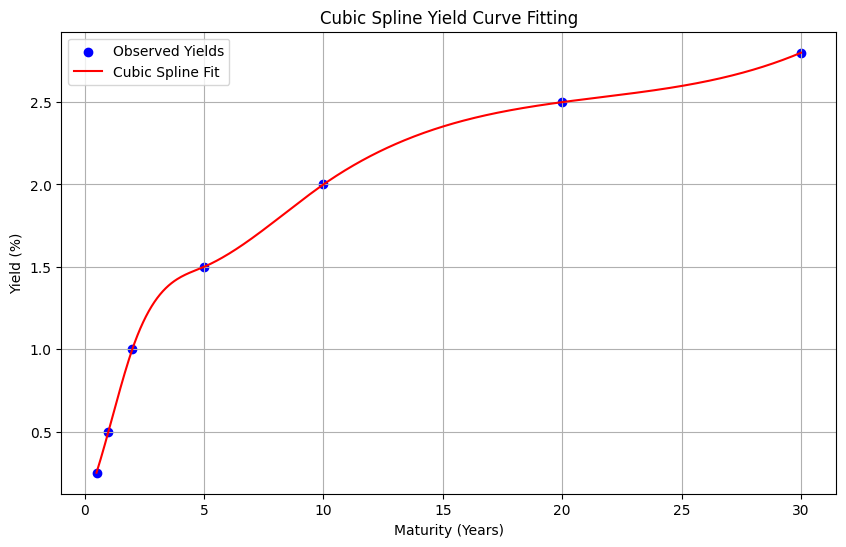

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Data: Maturities (in years) and yields
maturities = np.array([0.5, 1, 2, 5, 10, 20, 30])  # Example maturities
yields = np.array([0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 2.8])  # Example yields

# Fit the cubic spline
cs = CubicSpline(maturities, yields)

# Generate a smooth set of maturities for plotting
smooth_maturities = np.linspace(min(maturities), max(maturities), 500)
smooth_yields = cs(smooth_maturities)

# Plot the observed yields and cubic spline fit
plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color="blue", label="Observed Yields")
plt.plot(smooth_maturities, smooth_yields, color="red", label="Cubic Spline Fit")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Cubic Spline Yield Curve Fitting")
plt.legend()
plt.grid()
plt.show()

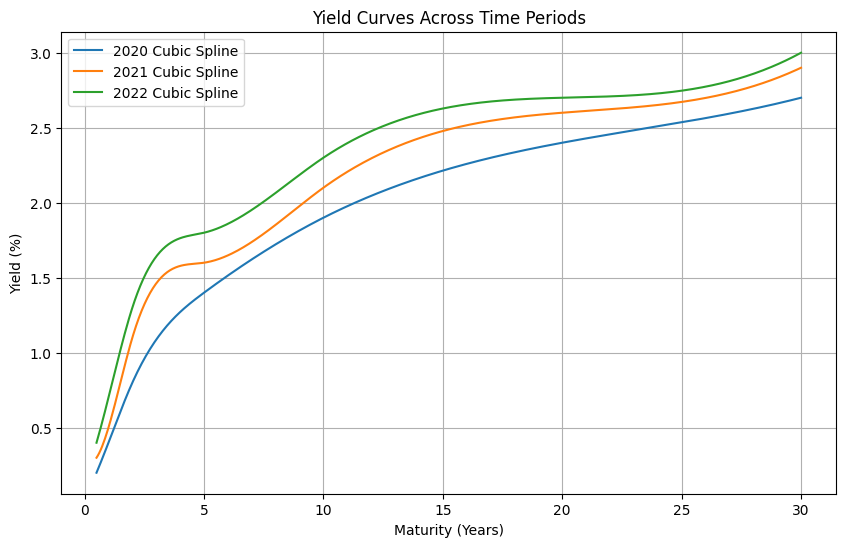

In [ ]:
# Fitting multiple cubic splines for different periods
time_periods = ["2020", "2021", "2022"]  # Example periods
yield_data = {
    "2020": (np.array([0.5, 1, 2, 5, 10, 20, 30]), np.array([0.2, 0.4, 0.8, 1.4, 1.9, 2.4, 2.7])),
    "2021": (np.array([0.5, 1, 2, 5, 10, 20, 30]), np.array([0.3, 0.5, 1.1, 1.6, 2.1, 2.6, 2.9])),
    "2022": (np.array([0.5, 1, 2, 5, 10, 20, 30]), np.array([0.4, 0.7, 1.3, 1.8, 2.3, 2.7, 3.0]))
}

plt.figure(figsize=(10, 6))
for period, (mats, ys) in yield_data.items():
    cs = CubicSpline(mats, ys)
    smooth_mats = np.linspace(min(mats), max(mats), 500)
    smooth_ys = cs(smooth_mats)
    plt.plot(smooth_mats, smooth_ys, label=f"{period} Cubic Spline")

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curves Across Time Periods")
plt.legend()
plt.grid()
plt.show()

Question 2 (e).

In [ ]:
import pandas as pd
from tabulate import tabulate

# Define the data
data = {
    "Feature": [
        "Flexibility",
        "Fit Quality",
        "Risk of Overfitting",
        "Interpretation",
        "Data Requirements",
        "Applications",
    ],
    "Nelson-Siegel Model": [
        "Low - Limited to parametric form",
        "Good for smooth, typical yield curves",
        "Low - Constrained by parametric form",
        "Strong - Parameters link to economic factors",
        "Minimal - Can fit well with fewer data points",
        "Economic analysis, macroeconomic modeling, policy analysis",
    ],
    "Cubic Spline Model": [
        "High - Fits any data shape",
        "Excellent for yield curves with local variations",
        "High - Sensitive to noise and irregularities",
        "Weak - No global parameters, focus is on precise fit",
        "High - Needs sufficient data points for reliable fitting",
        "Financial market analysis, pricing, and hedging.",
    ],
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the table in the console
print(tabulate(df, headers="keys", tablefmt="grid"))

# Save the table to an HTML file for presentation purposes
df.to_html("comparison_table.html", index=False)
print("\nTable saved as 'comparison_table.html'")

+----+---------------------+------------------------------------------------------------+----------------------------------------------------------+
|    | Feature             | Nelson-Siegel Model                                        | Cubic Spline Model                                       |
+====+=====================+============================================================+==========================================================+
|  0 | Flexibility         | Low - Limited to parametric form                           | High - Fits any data shape                               |
+----+---------------------+------------------------------------------------------------+----------------------------------------------------------+
|  1 | Fit Quality         | Good for smooth, typical yield curves                      | Excellent for yield curves with local variations         |
+----+---------------------+------------------------------------------------------------+-----------------

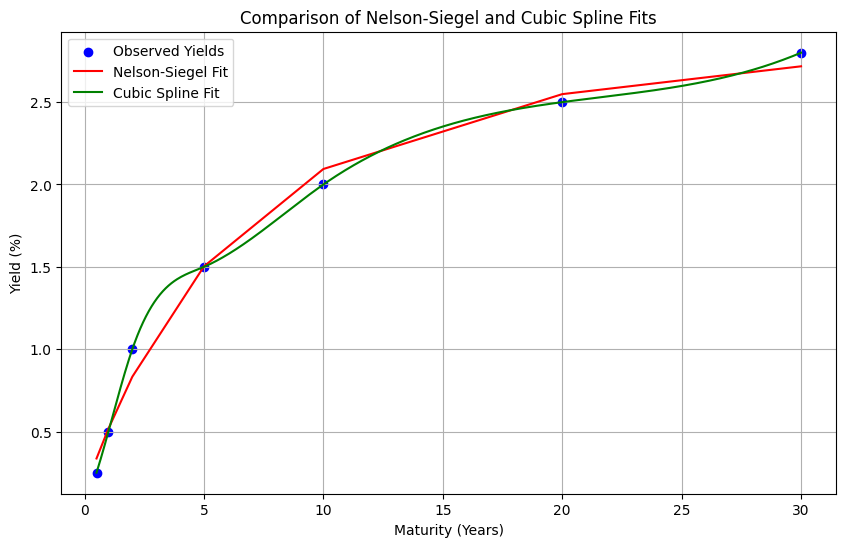

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit

# Data
maturities = np.array([0.5, 1, 2, 5, 10, 20, 30])  # Maturities in years
yields = np.array([0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 2.8])  # Corresponding yields

# Nelson-Siegel function
def nelson_siegel(maturities, beta0, beta1, beta2, lambda_):
    term1 = beta0
    term2 = beta1 * ((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_))
    term3 = beta2 * (((1 - np.exp(-maturities / lambda_)) / (maturities / lambda_)) - np.exp(-maturities / lambda_))
    return term1 + term2 + term3

# Fit Nelson-Siegel
initial_guess = [2.5, -1.0, 0.5, 0.5]
params, _ = curve_fit(nelson_siegel, maturities, yields, p0=initial_guess)
ns_fitted_yields = nelson_siegel(maturities, *params)

# Fit Cubic Spline
cs = CubicSpline(maturities, yields)
smooth_maturities = np.linspace(min(maturities), max(maturities), 500)
cs_fitted_yields = cs(smooth_maturities)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color="blue", label="Observed Yields")
plt.plot(maturities, ns_fitted_yields, color="red", label="Nelson-Siegel Fit")
plt.plot(smooth_maturities, cs_fitted_yields, color="green", label="Cubic Spline Fit")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Comparison of Nelson-Siegel and Cubic Spline Fits")
plt.legend()
plt.grid()
plt.show()

Question 2 (f).

In [ ]:
import pandas as pd
from tabulate import tabulate

# Define the data
data = {
    "Aspect": [
        "Long-term yield (β₀)",
        "Slope (β₁)",
        "Curvature (β₂)",
        "Decay (λ)",
        "Parameter Count",
    ],
    "Nelson-Siegel Model": [
        "Explicitly modeled as a parameter; interprets the level of the curve.",
        "Modeled explicitly; controls the steepness of the curve.",
        "Explicitly modeled; describes the hump in medium-term maturities.",
        "A global decay factor controls the influence of slope and curvature on longer maturities.",
        "4 parameters: β₀, β₁, β₂, λ.",
    ],
    "Cubic Spline Model": [
        "Implicitly captured by the spline at the highest maturity.",
        "Implicitly captured by the spline between short- and long-term maturities.",
        "Captured locally by the spline at medium maturities.",
        "No global decay factor; local adjustments based on maturity.",
        "No fixed parameter count; determined by the number of knots.",
    ],
}

# Create a DataFrame
df = pd.DataFrame(data)

# Display the table in the console
print(tabulate(df, headers="keys", tablefmt="grid"))

# Save the table to an HTML file for presentation purposes
df.to_html("parameter_comparison_table.html", index=False)
print("\nTable saved as 'parameter_comparison_table.html'")

+----+----------------------+-------------------------------------------------------------------------------------------+----------------------------------------------------------------------------+
|    | Aspect               | Nelson-Siegel Model                                                                       | Cubic Spline Model                                                         |
+====+======================+===========================================================================================+============================================================================+
|  0 | Long-term yield (β₀) | Explicitly modeled as a parameter; interprets the level of the curve.                     | Implicitly captured by the spline at the highest maturity.                 |
+----+----------------------+-------------------------------------------------------------------------------------------+----------------------------------------------------------------------------+
|  1 

In [ ]:
# Fit Nelson-Siegel model
params, _ = curve_fit(nelson_siegel, maturities, yields, p0=initial_guess)

# Extract parameters
beta0, beta1, beta2, lambda_ = params
print(f"Nelson-Siegel Parameters:\nBeta_0 (Level): {beta0:.4f}\nBeta_1 (Slope): {beta1:.4f}\nBeta_2 (Curvature): {beta2:.4f}\nLambda (Decay): {lambda_:.4f}")

Nelson-Siegel Parameters:
Beta_0 (Level): 3.0586
Beta_1 (Slope): -2.9209
Beta_2 (Curvature): -0.0001
Lambda (Decay): 3.5038


In [ ]:
# Fit Cubic Spline
cs = CubicSpline(maturities, yields)

# Inspect coefficients for each segment
print("Cubic Spline Coefficients:")
for i in range(len(cs.c.T)):
    print(f"Segment {i}: {cs.c.T[i]}")

Cubic Spline Coefficients:
Segment 0: [-0.05356511  0.10713022  0.45982617  0.25      ]
Segment 1: [-0.05356511  0.02678256  0.52678256  0.5       ]
Segment 2: [ 0.01652807 -0.13391278  0.41965233  1.        ]
Segment 3: [-1.46532479e-03  1.48398902e-02  6.24336688e-02  1.50000000e+00]
Segment 4: [ 2.04666057e-04 -7.13998170e-03  1.00933211e-01  2.00000000e+00]
Segment 5: [ 2.04666057e-04 -1.00000000e-03  1.95333943e-02  2.50000000e+00]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

QUESTION 3(a).

In [ ]:
#uncorrelated random variables have a covariance of zero.

# Set seed for reproducibility
np.random.seed(42)

# Generate 5 uncorrelated Gaussian random variables (mean=0, std=0.1)
n_samples = 100
uncorrelated_data = np.random.normal(0, 0.1, (n_samples, 5))
columns = ['Variable1', 'Variable2', 'Variable3', 'Variable4', 'Variable5']
uncorrelated_df = pd.DataFrame(uncorrelated_data, columns=columns)

# Display a sample
print(uncorrelated_df.head())


   Variable1  Variable2  Variable3  Variable4  Variable5
0   0.049671  -0.013826   0.064769   0.152303  -0.023415
1  -0.023414   0.157921   0.076743  -0.046947   0.054256
2  -0.046342  -0.046573   0.024196  -0.191328  -0.172492
3  -0.056229  -0.101283   0.031425  -0.090802  -0.141230
4   0.146565  -0.022578   0.006753  -0.142475  -0.054438


In [ ]:
# Compute the covariance matrix
cov_matrix = uncorrelated_df.cov()

# Print the covariance matrix
print("Covariance Matrix:")
print(cov_matrix)


Covariance Matrix:
           Variable1  Variable2  Variable3  Variable4  Variable5
Variable1   0.008106  -0.001448   0.000397  -0.000880  -0.001219
Variable2  -0.001448   0.009685   0.001189   0.000361   0.000603
Variable3   0.000397   0.001189   0.009681   0.000080   0.000452
Variable4  -0.000880   0.000361   0.000080   0.009207   0.000189
Variable5  -0.001219   0.000603   0.000452   0.000189   0.011509


Question 3(b).

In [ ]:


# Perform PCA using the correlation matrix
pca = PCA()
pca.fit(uncorrelated_df)

# Explained variance ratios
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratios:", explained_variance)


Explained Variance Ratios: [0.26256655 0.21579693 0.20219416 0.18127308 0.13816928]


**Screeplot**

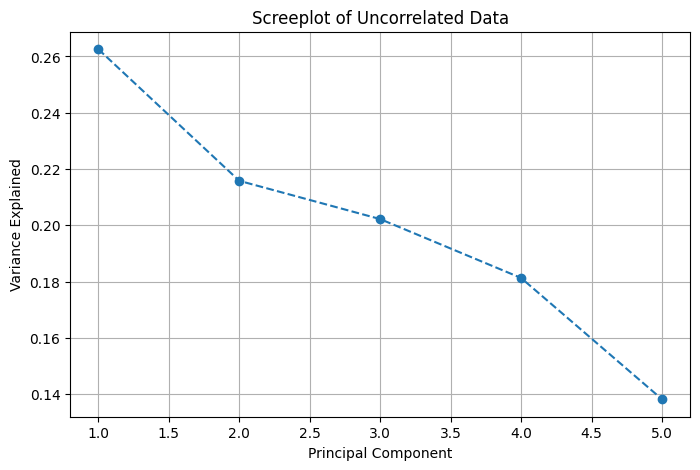

In [ ]:
# Screeplot
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), explained_variance, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Screeplot of Uncorrelated Data')
plt.grid(True)
plt.show()


QUESTION 3(e).

In [ ]:


# Define start and end dates
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

# Fetch U.S. Treasury yield data from FRED
# Short-term (3-Month), Medium-term (2-Year), Long-term (10-Year)
treasury_3m = web.DataReader("DGS3MO", "fred", start_date, end_date)
treasury_2y = web.DataReader("DGS2", "fred", start_date, end_date)
treasury_10y = web.DataReader("DGS10", "fred", start_date, end_date)

# Combine data into a single DataFrame
yields_df = pd.concat([treasury_3m, treasury_2y, treasury_10y], axis=1)
yields_df.columns = ['3-Month', '2-Year', '10-Year']

# Display the data
print(yields_df.head())

# Save to CSV for future use
yields_df.to_csv('us_treasury_yields.csv')


            3-Month  2-Year  10-Year
DATE                                
2023-01-02      NaN     NaN      NaN
2023-01-03     4.53    4.40     3.79
2023-01-04     4.55    4.36     3.69
2023-01-05     4.66    4.45     3.71
2023-01-06     4.67    4.24     3.55


Question 3(f).

In [ ]:
# Compute daily yield changes as the difference from the previous day
daily_yield_changes = yields_df.diff()

# Display the daily yield changes
print("Daily Yield Changes:")
print(daily_yield_changes.head())


Daily Yield Changes:
            3-Month  2-Year  10-Year
DATE                                
2023-01-02      NaN     NaN      NaN
2023-01-03      NaN     NaN      NaN
2023-01-04     0.02   -0.04    -0.10
2023-01-05     0.11    0.09     0.02
2023-01-06     0.01   -0.21    -0.16


Question 3(g).

In [ ]:



# Drop rows with NaN values due to differencing
daily_yield_changes.dropna(inplace=True)

# Choose either the correlation matrix or covariance matrix
correlation_matrix = daily_yield_changes.corr()
covariance_matrix = daily_yield_changes.cov()

# Display the matrices (optional)
print("Correlation Matrix:\n", correlation_matrix)
print("Covariance Matrix:\n", covariance_matrix)


# Perform PCA using correlation or covariance matrix
pca = PCA()

# Fit PCA to the daily yield changes (using the raw data, as the matrix is handled internally)
pca.fit(daily_yield_changes)

# Explained variance ratio for each principal component
explained_variance_ratios = pca.explained_variance_ratio_
print("Explained Variance Ratios by Component:", explained_variance_ratios)


Correlation Matrix:
           3-Month    2-Year   10-Year
3-Month  1.000000  0.424073  0.326288
2-Year   0.424073  1.000000  0.797849
10-Year  0.326288  0.797849  1.000000
Covariance Matrix:
           3-Month    2-Year   10-Year
3-Month  0.001254  0.001217  0.000761
2-Year   0.001217  0.006564  0.004255
10-Year  0.000761  0.004255  0.004334
Explained Variance Ratios by Component: [0.82941516 0.09681079 0.07377405]


Question 3(i).

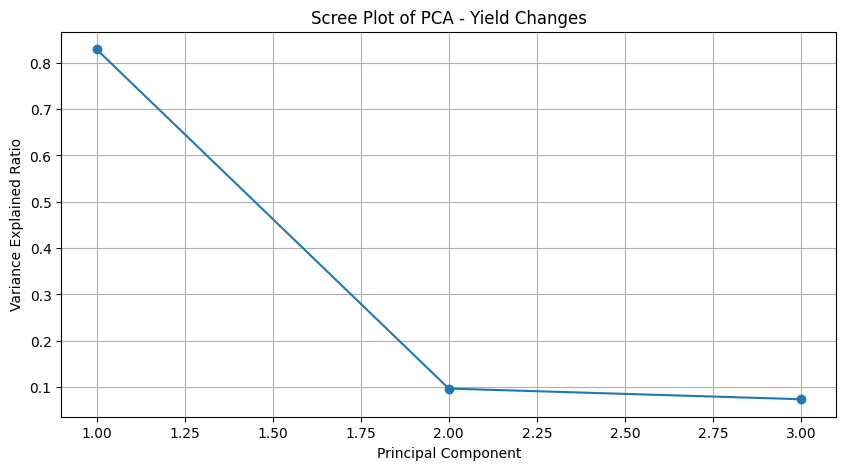

In [ ]:
# Scree plot of variance explained
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance_ratios) + 1), explained_variance_ratios, marker='o', linestyle='-')
plt.title("Scree Plot of PCA - Yield Changes")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained Ratio")
plt.grid(True)
plt.show()
